In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0


In [19]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [20]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]

print("After preprocessing:")
print("Train:", x_train.shape)
print("Test :", x_test.shape)

After preprocessing:
Train: (60000, 28, 28, 1)
Test : (10000, 28, 28, 1)


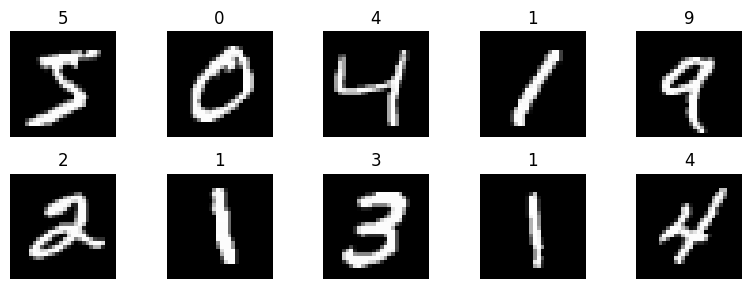

In [21]:
plt.figure(figsize=(8,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(int(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

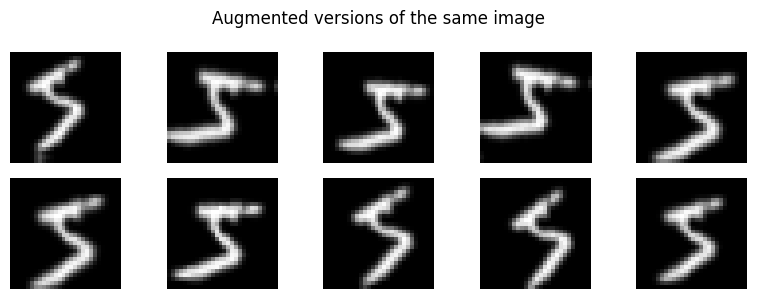

In [23]:
sample = x_train[0:1]  # one image

plt.figure(figsize=(8,3))
for i in range(10):
    augmented = data_augmentation(sample, training=True)
    plt.subplot(2,5,i+1)
    plt.imshow(augmented[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Augmented versions of the same image")
plt.tight_layout()
plt.show()

In [24]:
class MinPooling2D(layers.Layer):
    def __init__(self, pool_size=(2,2), strides=None, padding="valid"):
        super(MinPooling2D, self).__init__()
        self.pool = layers.MaxPooling2D(pool_size=pool_size,
                                        strides=strides,
                                        padding=padding)

    def call(self, inputs):
        return -self.pool(-inputs)



def build_cnn_with_dropout():
    model_min = models.Sequential([
        layers.Input(shape=(28,28,1)),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation="relu"),
        MinPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation="relu"),
        MinPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.50),
        layers.Dense(10, activation="softmax")
    ], name="CNN_WithMinPooling")
    return model_min
model_a = build_cnn_with_dropout()
model_a.summary()

Model: "CNN_WithMinPooling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ min_pooling2d_2 (MinPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ min_pooling2d_3 (MinPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# def build_cnn_baseline():
#     model = models.Sequential([
#         layers.Input(shape=(28,28,1)),
#         data_augmentation,
#         layers.Conv2D(32, (3,3), activation="relu"),
#         layers.MaxPooling2D((2,2)),
#         layers.Conv2D(64, (3,3), activation="relu"),
#         layers.MaxPooling2D((2,2)),
#         layers.Flatten(),
#         layers.Dense(128, activation="relu"),
#         layers.Dense(10, activation="softmax")
#     ], name="CNN_Baseline_NoDropout")
#     return model

# model_a = build_cnn_baseline()
# model_a.summary()

In [26]:
model_a.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_a = model_a.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 131ms/step - accuracy: 0.5434 - loss: 1.3639 - val_accuracy: 0.9533 - val_loss: 0.1612
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 127ms/step - accuracy: 0.8308 - loss: 0.5410 - val_accuracy: 0.9666 - val_loss: 0.1065
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 130ms/step - accuracy: 0.8731 - loss: 0.4087 - val_accuracy: 0.9744 - val_loss: 0.0889
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.8904 - loss: 0.3586 - val_accuracy: 0.9782 - val_loss: 0.0729
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - accuracy: 0.9039 - loss: 0.3204 - val_accuracy: 0.9764 - val_loss: 0.0788


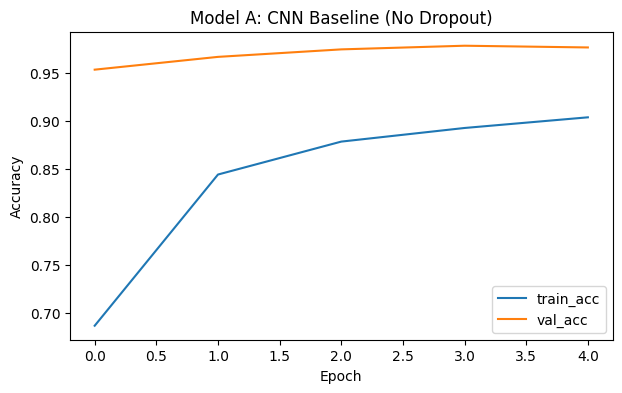

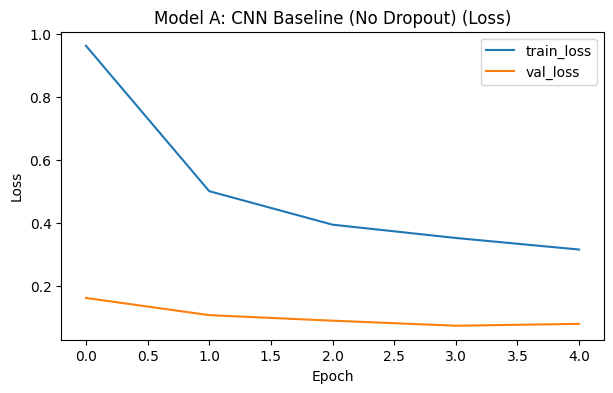

In [27]:
def plot_history(history, title):
    plt.figure(figsize=(7,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " (Loss)")
    plt.legend()
    plt.show()

plot_history(history_a, "Model A: CNN Baseline (No Dropout)")

In [28]:
def build_cnn_with_dropout():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.50),
        layers.Dense(10, activation="softmax")
    ], name="CNN_WithDropout")
    return model

model_b = build_cnn_with_dropout()
model_b.summary()

Model: "CNN_WithDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model_b.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_b = model_b.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 130ms/step - accuracy: 0.5972 - loss: 1.1850 - val_accuracy: 0.9713 - val_loss: 0.0861
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 128ms/step - accuracy: 0.8918 - loss: 0.3491 - val_accuracy: 0.9814 - val_loss: 0.0513
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 129ms/step - accuracy: 0.9188 - loss: 0.2683 - val_accuracy: 0.9864 - val_loss: 0.0390
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 128ms/step - accuracy: 0.9313 - loss: 0.2282 - val_accuracy: 0.9883 - val_loss: 0.0361
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 131ms/step - accuracy: 0.9413 - loss: 0.1943 - val_accuracy: 0.9892 - val_loss: 0.0313


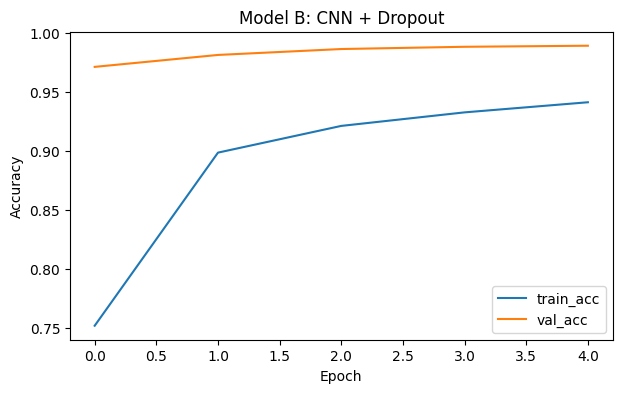

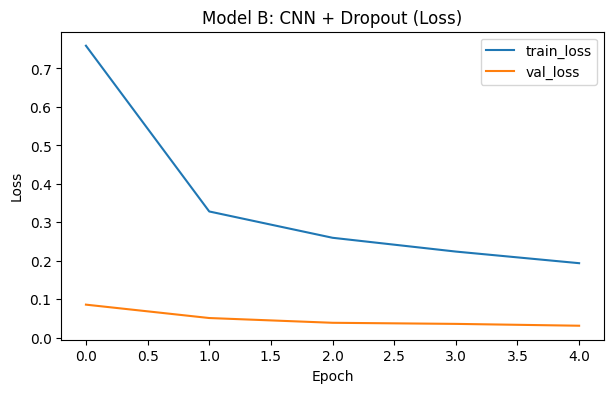

In [30]:
plot_history(history_b, "Model B: CNN + Dropout")

In [31]:
test_loss_a, test_acc_a = model_a.evaluate(x_test, y_test, verbose=0)
test_loss_b, test_acc_b = model_b.evaluate(x_test, y_test, verbose=0)

print("Model A (No Dropout)  - Test Accuracy:", round(test_acc_a, 4), " Test Loss:", round(test_loss_a, 4))
print("Model B (With Dropout) - Test Accuracy:", round(test_acc_b, 4), " Test Loss:", round(test_loss_b, 4))

Model A (No Dropout)  - Test Accuracy: 0.9764  Test Loss: 0.0788
Model B (With Dropout) - Test Accuracy: 0.9892  Test Loss: 0.0313


Predictions using Model B (Dropout):


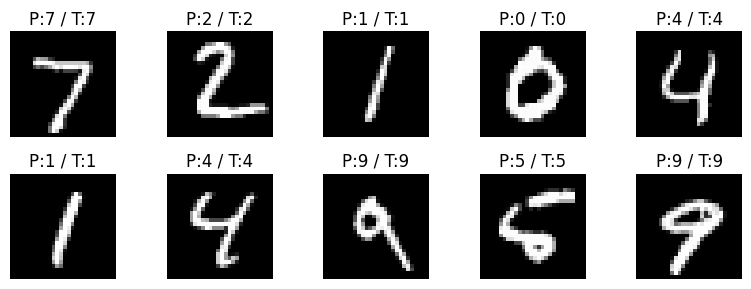

In [32]:
def show_predictions(model, x, y, n=10):
    preds = model.predict(x[:n], verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(8,3))
    for i in range(n):
        plt.subplot(2,5,i+1)
        plt.imshow(x[i].squeeze(), cmap="gray")
        plt.title(f"P:{pred_labels[i]} / T:{y[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Predictions using Model B (Dropout):")
show_predictions(model_b, x_test, y_test, n=10)